# Initialization
Importing all that stuff and defining drawing routines. 

In [1]:
import numpy as np
import RandomTilings as RT
from RandomTilings._draw_dominos import draw_dominos
from RandomTilings._core import no_neighbor
from RandomTilingsTMP._draw_dominos import draw_dominos as draw_dominosTMP
from numba import jit,njit
from numba.typed import List 
from time import perf_counter
RT.config.set_hd_mode(1)
from mpmath import mp
mp.pretty = 1

weight_aztec = RT._weight_aztec.weight_aztec
def draw_Aztec(M,edge=0,paths=False,dots=False,orientation='diamond',coloring='standard',
                   show_gap=False,dpi=100):
        edge = str(edge)
        return draw_dominos(M,False,edge,paths,dots,orientation,coloring,show_gap,dpi)

def draw_AztecTMP(M,edge=0,paths=False,dots=False,rotated=True,coloring='standard',
                   show_gap=False,dpi=100,show_figure=False):
        edge = str(edge)
        return draw_dominosTMP(M,False,edge,paths,dots,rotated,coloring,show_gap,dpi,show_figure)

tilings. However, large tilings require extreme amount of storage, hence all relveant
data will immediately stored on the hard drive. Therefore, it is important to free
the storage after usage. To free the storage use the comand "close", for example if
"A" is your random tiling call "A.close()" to free the storage. Also, never use more
then one random tiling with enabled hard drive mode, since they will overwrite each
others data. Consequenctly, they can not be properly shuffeld of plotted.


# Main Routine

In [2]:
def update_weight(W,E):
    M,N = W.shape
    M,N = M//2,N//2
    W1 = W.copy() + 1*(W==0)
    E1 = E.copy() + 1*(W==0)
    for m in range(M):
        for n in range(N):
            w,x,y,z     = W1[2*m,2*n],W1[2*m,2*n+1],W1[2*m+1,2*n],W1[2*m+1,2*n+1]
            ew,ex,ey,ez = E1[2*m,2*n],E1[2*m,2*n+1],E1[2*m+1,2*n],E1[2*m+1,2*n+1]

            Ixy = ex+ey
            Iwz = ew+ez
            if Ixy>Iwz:
                d           = w*z 
                w,x,y,z     = 1/w,y/d,x/d,1/z
                ew,ex,ey,ez = -ew,ey-Iwz,ex-Iwz,-ez
            elif Ixy<Iwz:
                d           = x*y
                w,x,y,z     = z/d,1/x,1/y,w/d
                ew,ex,ey,ez = ez-Ixy,-ex,-ey,ew-Ixy
            else:
                d           = w*z + x*y
                w,x,y,z     = z/d, y/d, x/d, w/d
                ew,ex,ey,ez = ez-Ixy,ey-Ixy,ex-Ixy,ew-Ixy

            W1[2*m,2*n],W1[2*m,2*n+1],W1[2*m+1,2*n],W1[2*m+1,2*n+1] = w,x,y,z
            E1[2*m,2*n],E1[2*m,2*n+1],E1[2*m+1,2*n],E1[2*m+1,2*n+1] = ew,ex,ey,ez

    I1 = np.concat([np.arange(1,2*N),[0]])
    I2 = np.concat([[-1],np.arange(2*M-1)])

    W1 = W1[:,I1]
    W1 = W1[I2]
    E1 = E1[:,I1]
    E1 = E1[I2]
    return W1,E1

def comp_prop(W,E):
    M,N = W.shape
    M,N = M//2,N//2

    P   = np.zeros((M,N)).astype('O')
    for m in range(M):
        for n in range(N):
            w,x,y,z     = W[2*m,2*n],W[2*m,2*n+1],W[2*m+1,2*n],W[2*m+1,2*n+1]
            ew,ex,ey,ez = E[2*m,2*n],E[2*m,2*n+1],E[2*m+1,2*n],E[2*m+1,2*n+1]

            Ixy = ex+ey
            Iwz = ew+ez
            if Ixy>Iwz:
                P[m,n] = 1
                continue
            elif Ixy < Iwz:
                P[m,n] = 0
                continue
            tmp = (w*z+x*y)
            if tmp == 0 :
                P[m,n] = 1/2
            else:
                P[m,n] = w*z/(w*z+x*y)
    return P


@njit("(int64, int64, int64, int64, int64)",inline = 'always')
def idx_correction(Size,WShape1,WShape2,m,n):
    m = WShape1 - (Size-m-1) % WShape1 - 1
    n = n % WShape2 
    return m,n

def comp_PTower(N,W,E):
    L1,L2 = W.shape
    if L1%2==1:
        W = np.vstack([W,W])
        E = np.vstack([E,E])
    if L2%2==1:
        W = np.hstack([W,W])
        E = np.hstack([E,E])
    PT = [comp_prop(W,E).astype(float)]
    for _ in range(N-1):
        W,E = update_weight(W,E)
        PT += [comp_prop(W,E).astype(float)]
    return List(PT[::-1])


@njit("(ListType(Array(float64, 2, 'C', False, aligned=True)),)")         
def shuffling(PT):
    N = 2*len(PT)
    M = np.zeros((N,N),dtype=np.int8)

    # Initiate
    A = N//2-1
    prob = PT[0][1,0]
    #print(PT[0])


    L1,L2 = PT[0].shape

    if np.random.random()<prob:
        M[A,A],M[A+1,A+1]= 1,1
        M[A,A+1],M[A+1,A]= 0,0
    else:
        M[A,A],M[A+1,A+1]= 0,0
        M[A,A+1],M[A+1,A]= 1,1

    
    for k in range(1,N//2):
        A = N//2-1-k   

        # destruction + flip (+ reconstruct)
        for m in range(k+1):
            for n in range(k+1):
                # destruction + flip
                tmp = M[A+2*m,A+2*n]+M[A+2*m+1,A+2*n]+M[A+2*m,A+2*n+1]+M[A+2*m+1,A+2*n+1]
                if tmp>1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n+1]=0,0,0,0
                elif tmp == 1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]=M[A+2*m+1,A+2*n+1],M[A+2*m,A+2*n]
                    M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]=M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1]

        for m in range(k+1):
            for n in range(k+1):
                if no_neighbor(M,k,m,n):
                    
                    # r = L1 - (k-m) % L2 - 1
                    # s = n % L2
                    r,s = idx_correction(k+1,L1,L2,m,n)
                    prob = PT[k][r,s]


                    if np.random.random()<prob:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 1,1
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 0,0
                    else:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 0,0
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 1,1
    return M

    

# Test Aztec

Reduction	 0.027532600099220872
Shuffling 	 3.515220500063151
Plotting  	 2.585013199946843
-------------------------------------
Total     	 6.128325599944219


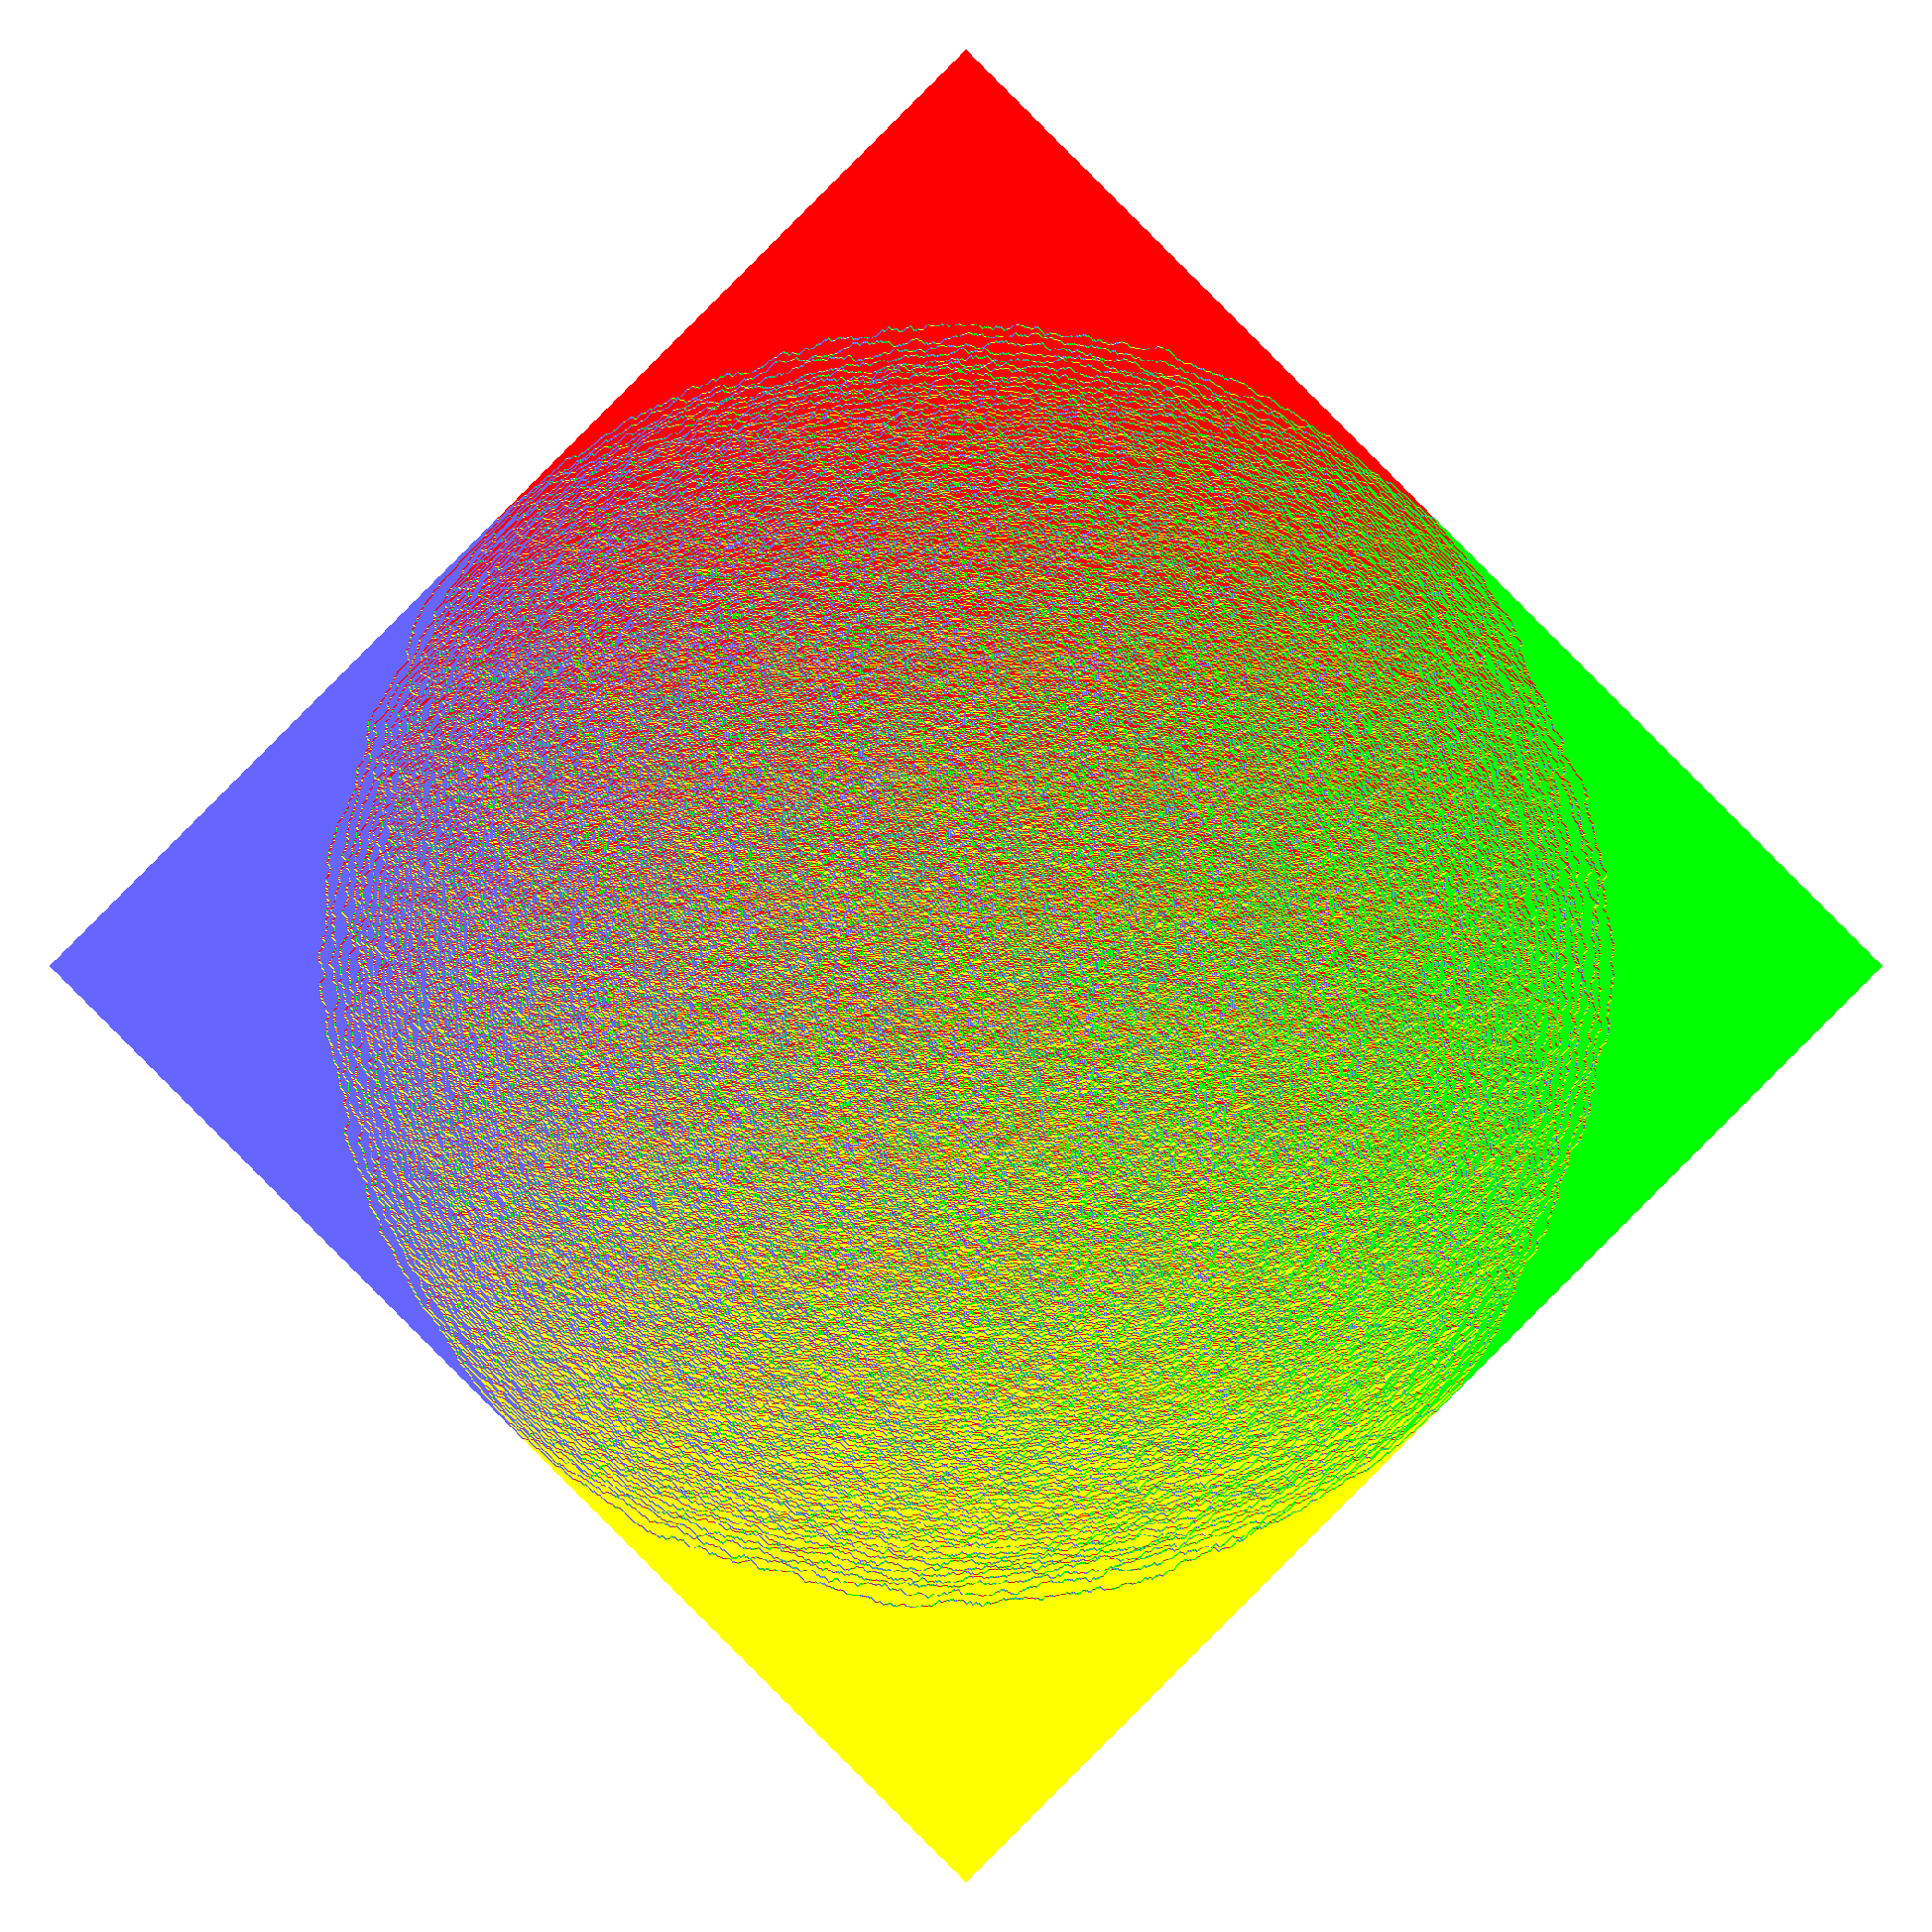

In [16]:
n = 1000
w = np.array([[1.]])
mp.dps = 100

vec_mpf = np.vectorize(mp.mpf)

use_mp = False
w1 = [w,vec_mpf(w.real)][use_mp]

t0 = perf_counter()
t1 = perf_counter()
PT = comp_PTower(n,w1,w.imag)
print('Reduction\t',perf_counter()-t1)
t1 = perf_counter()
M = shuffling(PT).astype(np.int8)
print('Shuffling \t',perf_counter()-t1)
t1 = perf_counter()
fig = draw_Aztec(M,dpi =500)
print('Plotting  \t',perf_counter()-t1)
print('-------------------------------------')
print('Total     \t', perf_counter()-t0)

# Fun Stuff

Reduction	 0.11976819997653365
Shuffling 	 1.700233899988234
Plotting  	 3.1369652000721544
------------------------------------
Total     	 4.957475400064141


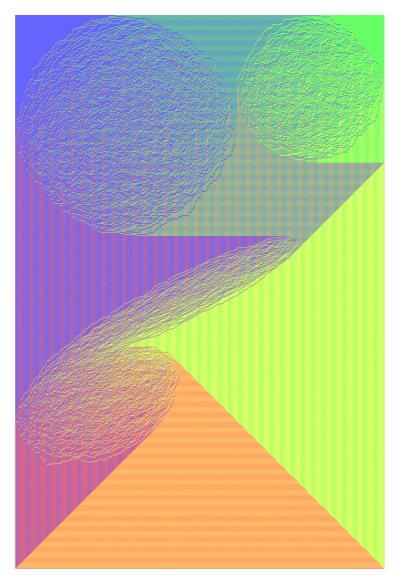

In [28]:
n      = 1000
mp.dps = 10
r      = 1


def diff(theta,phi):
    return np.abs(np.sin((theta-phi)/2))

alpha = 0.
beta = np.pi/25
gamma = 4*np.pi/5
delta = 6*np.pi/5
epsilon = 8*np.pi/5


w = np.array([[1+1j,diff(epsilon,gamma),diff(gamma,beta),diff(delta,gamma),diff(gamma,beta),diff(beta,gamma)],
[diff(gamma,beta),diff(beta,epsilon),1+r*1j,diff(beta,delta),1+1j,1+r*1j],
[diff(delta,gamma),diff(epsilon,delta),diff(delta,beta),1+1j,diff(delta,alpha),diff(alpha,delta)],
[diff(gamma,alpha),diff(alpha,epsilon),diff(beta,alpha),diff(alpha,delta),1+r*1j,1+1j]])

# w = np.hstack([w,w,w,w])
# w = np.vstack([w,w,w,w,w,w])





vec_mpf = np.vectorize(mp.mpf)

t0 = perf_counter()
t1 = perf_counter()
PT = comp_PTower(n,vec_mpf(w.real),w.imag)
print('Reduction\t',perf_counter()-t1)
t1 = perf_counter()
M = shuffling(PT).astype(np.int8)
print('Shuffling \t',perf_counter()-t1)
t1 = perf_counter()
fig = draw_Aztec(M,coloring=[(255,33,33),(31,31,255),(32,255,32),(255,255,32)],
                 orientation='square',dpi =150)
ax = fig.axes[0]
ax.set_aspect(3/2,adjustable='box')
ax.invert_yaxis()
ax.invert_xaxis()
fig
print('Plotting  \t',perf_counter()-t1)
print('------------------------------------')
print('Total     \t', perf_counter()-t0)

In [211]:
n = 300
d = 4
w = np.random.random((d,d))

w = np.array([[1+1j,diff(epsilon,gamma),diff(gamma,beta),diff(delta,gamma),diff(gamma,beta),diff(beta,gamma)],
[diff(gamma,beta),diff(beta,epsilon),1+r*1j,diff(beta,delta),1+1j,1+r*1j],
[diff(delta,gamma),diff(epsilon,delta),diff(delta,beta),1+1j,diff(delta,alpha),diff(alpha,delta)],
[diff(gamma,alpha),diff(alpha,epsilon),diff(beta,alpha),diff(alpha,delta),1+r*1j,1+1j]])

vec_mpf = np.vectorize(mp.mpf)
PT = comp_PTower(n,vec_mpf(w.real),w.imag)[::-1]

err = [np.max(abs(PT[0]-PT[k])) for k in range(n)]



In [220]:
for k in range(n):
    if err[k]<1e-5:
        print(k,'\t',err[k])

0 	 0.0
30 	 0.0
60 	 0.0
90 	 0.0
120 	 0.0
150 	 0.0
180 	 0.0
210 	 0.0
240 	 0.0
270 	 0.0


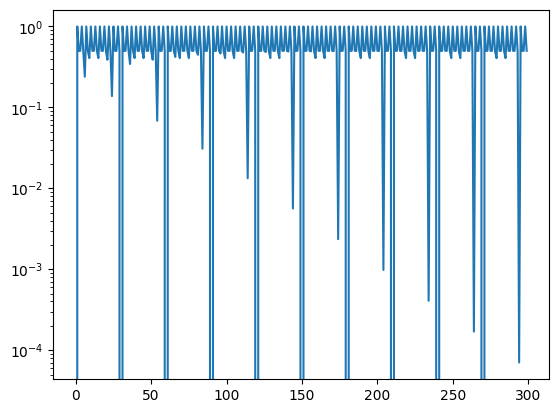

In [212]:
import matplotlib.pyplot as plt
plt.plot(err)
plt.yscale('log')

In [179]:
PT[0]

array([[0.72320083, 0.01059804],
       [0.63872181, 0.24345687]])

In [187]:
k = 8
PT[k]

array([[0.42176047, 0.03695189],
       [0.86362923, 0.08243108]])

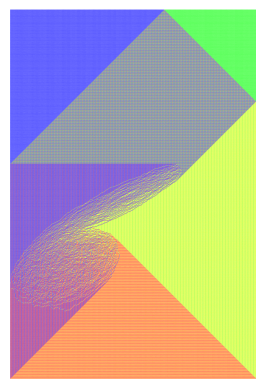

In [56]:
_=draw_dominos_vectorized(M[::-1,::-1],coloring='(32,255,32),(255,255,32),(255,33,33),(31,31,255)')

In [245]:
np.random.randint(2)

1

In [64]:
from matplotlib.collections import PolyCollection, LineCollection
from matplotlib import transforms
from numba import njit
import matplotlib.pyplot as plt
import numpy as np
import re


# ------------------------------------------------------------
# Keep your existing njit helper functions below unchanged:
# type_of_domino, points_path, points_domino, compute_points,
# compute_points_dots, ext_type_of_domino, ext_compute_points
# ------------------------------------------------------------


# ------------------------------------------------------------
# New helpers for vectorized polygon creation
# ------------------------------------------------------------

DEFAULT_CUSTOM_COLORING = '(255,33,33),(31,31,255),(32,255,32),(255,255,32)'


def _parse_rgb_coloring(coloring, expected_len):
    rgb_values = [
        tuple(float(val) / 255 for val in rgb)
        for rgb in re.findall(r'\((\d+),(\d+),(\d+)\)', coloring)
    ]
    if len(rgb_values) != expected_len:
        raise ValueError(
            f"Invalid coloring. Expected {expected_len} RGB tuples, got {len(rgb_values)}."
        )
    return rgb_values


def _active_centers(M):
    """
    Return centers of active dominoes in the same coordinate convention
    as your original compute_points code.
    """
    N = M.shape[0]
    rows, cols = np.nonzero(M)
    x = cols + 1
    y = N - rows
    centers = np.column_stack((x, y)).astype(float)
    return centers, x, y


def _build_polycollection(centers, template, facecolor, edge):
    if centers.shape[0] == 0:
        return None

    polys = centers[:, None, :] + template[None, :, :]

    coll = PolyCollection(
        polys,
        facecolors=facecolor,
        edgecolors='k',
        linewidths=edge,
        joinstyle='miter'       # sharper polygon corners
    )

    return coll


def _vectorized_base_collections(M, edge, coloring):
    """
    Fast replacement for the non-path, non-'aztec gray' branch.
    """
    centers, x, y = _active_centers(M)

    north = (x % 2 == 0) & (y % 2 == 0)
    east  = (x % 2 == 0) & (y % 2 == 1)
    south = (x % 2 == 1) & (y % 2 == 1)
    west  = (x % 2 == 1) & (y % 2 == 0)

    # same geometry as your points_domino() function
    template_NS = np.array([
        [-1.5,  0.5],
        [-0.5,  1.5],
        [ 1.5, -0.5],
        [ 0.5, -1.5],
    ], dtype=float)

    template_EW = np.array([
        [-1.5, -0.5],
        [ 0.5,  1.5],
        [ 1.5,  0.5],
        [-0.5, -1.5],
    ], dtype=float)

    if coloring == 'standard':
        color_north = (1, 0, 0)
        color_east  = (0, 1, 0)
        color_south = (1, 1, 0)
        color_west  = (0.4, 0.4, 1)
    elif coloring == 'alternative':
        color_north = (70/255, 60/255, 75/255)
        color_east  = (60/255, 120/255, 155/255)
        color_south = (190/255, 190/255, 140/255)
        color_west  = (195/255, 130/255, 60/255)
    elif coloring == 'gray':
        color_north = (0.8, 0.8, 0.8)
        color_east  = (0.6, 0.6, 0.6)
        color_south = (0.2, 0.2, 0.2)
        color_west  = (0.4, 0.4, 0.4)
    else:
        rgb_values = _parse_rgb_coloring(coloring, 4)
        color_north, color_east, color_south, color_west = rgb_values

    collections = {
        'north': _build_polycollection(centers[north], template_NS, color_north, edge),
        'east':  _build_polycollection(centers[east],  template_EW, color_east, edge),
        'south': _build_polycollection(centers[south], template_NS, color_south, edge),
        'west':  _build_polycollection(centers[west],  template_EW, color_west, edge),
    }
    return collections


def _vectorized_aztec_gray_collections(M, edge):
    """
    Fast replacement for the non-path 'aztec gray' branch.
    """
    centers, x, y = _active_centers(M)

    # ext_type_of_domino logic, but vectorized
    ext_type = np.empty_like(x)

    north = (x % 2 == 0) & (y % 2 == 0)
    east  = (x % 2 == 0) & (y % 2 == 1)
    south = (x % 2 == 1) & (y % 2 == 1)
    west  = (x % 2 == 1) & (y % 2 == 0)

    ext_type[north] = 1 + (((x[north] + y[north]) % 4) == 0).astype(int)
    ext_type[east]  = 3 + (((x[east]  - y[east])  % 4) == 1).astype(int)
    ext_type[south] = 5 + (((x[south] + y[south]) % 4) == 0).astype(int)
    ext_type[west]  = 7 + (((x[west]  - y[west])  % 4) == 1).astype(int)

    template_NS = np.array([
        [-1.5,  0.5],
        [-0.5,  1.5],
        [ 1.5, -0.5],
        [ 0.5, -1.5],
    ], dtype=float)

    template_EW = np.array([
        [-1.5, -0.5],
        [ 0.5,  1.5],
        [ 1.5,  0.5],
        [-0.5, -1.5],
    ], dtype=float)

    aztec_colors = {
        1: (6.5/9, 6.5/9, 6.5/9),
        2: (1.5/9, 1.5/9, 1.5/9),
        3: (6/9,   6/9,   6/9),
        4: (2/9,   2/9,   2/9),
        5: (1/9,   1/9,   1/9),
        6: (7/9,   7/9,   7/9),
        7: (2.5/9, 2.5/9, 2.5/9),
        8: (7.5/9, 7.5/9, 7.5/9),
    }

    collections = {}
    for t in range(1, 9):
        mask = (ext_type == t)
        template = template_NS if t in (1, 2, 5, 6) else template_EW
        collections[t] = _build_polycollection(centers[mask], template, aztec_colors[t], edge)

    return collections


# ------------------------------------------------------------
# Replacement draw_dominos
# ------------------------------------------------------------

def draw_dominos_vectorized(
    M,
    gap=False,
    edge=0,
    paths=False,
    dots=False,
    rotated=False,
    coloring=DEFAULT_CUSTOM_COLORING,
    show_gap=False,
    dpi=100,
    show_figure=True
):
    N = M.shape[0]
    path_scaling = 20 / N
    edge = float(edge)

    margin = 1
    fig, ax = plt.subplots(dpi=dpi)

    if rotated:
        ax.set_xlim(-(N + 1.5 + margin), 0.5 + margin)
        ax.set_ylim(-(N + 1.5 + margin), 0.5 + margin)
    else:
        ax.set_xlim(-0.5 - margin, N + 1.5 + margin)
        ax.set_ylim(-0.5 - margin, N + 1.5 + margin)

    ax.set_aspect(3 / 2, adjustable='box')
    ax.axis('off')

    created_collections = []

    # --------------------------------------------------------
    # Keep the original paths branch mostly unchanged
    # --------------------------------------------------------
    if paths:
        if coloring == 'standard':
            color_east = (0.4, 0.4, 1)
            color_south = (0.4, 0.4, 1)
            color_west = (0.4, 0.4, 1)
        else:
            # Support both 3-color and 4-color custom strings.
            # For a 4-color string we interpret it as:
            #   north, east, south, west
            rgb_values = [
                tuple(float(val) / 255 for val in rgb)
                for rgb in re.findall(r'\((\d+),(\d+),(\d+)\)', coloring)
            ]
            if len(rgb_values) == 3:
                color_east = rgb_values[0]
                color_south = rgb_values[1]
                color_west = rgb_values[2]
            elif len(rgb_values) == 4:
                _, color_east, color_south, color_west = rgb_values
            else:
                raise ValueError("Invalid coloring for paths=True.")

        points_north, points_east, points_south, points_west = compute_points(M, False)
        patch_north = ax.add_collection(PolyCollection(points_north, facecolor='none', edgecolor='k', linewidth=edge))
        patch_east  = ax.add_collection(PolyCollection(points_east,  facecolor='none', edgecolor='k', linewidth=edge))
        patch_south = ax.add_collection(PolyCollection(points_south, facecolor='none', edgecolor='k', linewidth=edge))
        patch_west  = ax.add_collection(PolyCollection(points_west,  facecolor='none', edgecolor='k', linewidth=edge))

        created_collections.extend([patch_north, patch_east, patch_south, patch_west])

        points_north, points_east, points_south, points_west = compute_points(M, True)
        lines_east  = ax.add_collection(LineCollection(points_east,  colors=color_east,  linewidths=path_scaling))
        lines_south = ax.add_collection(LineCollection(points_south, colors=color_south, linewidths=path_scaling))
        lines_west  = ax.add_collection(LineCollection(points_west,  colors=color_west,  linewidths=path_scaling))

        created_collections.extend([lines_east, lines_south, lines_west])

        if dots:
            points_south_dots, points_west_dots = compute_points_dots(M)
            if rotated:
                rot = (2**0.5 / 2) * np.array([[1, -1], [1, 1]])
                points_south_dots = points_south_dots @ rot.T
                points_west_dots = points_west_dots @ rot.T
            ax.scatter(points_south_dots[:, 0], points_south_dots[:, 1], color=color_south, linewidth=path_scaling / 2)
            ax.scatter(points_west_dots[:, 0], points_west_dots[:, 1], color=color_west, linewidth=path_scaling / 2)

        if show_gap:
            points_gap_lines = []
            size_gap = gap.shape[0]
            for i1 in range(size_gap):
                x = gap[i1][0]
                y1 = N - x + 2 * gap[i1][1] - 1
                y2 = N - x + 2 * gap[i1][2]
                points_gap_lines.append([[x, y1], [x, y2]])
            gap_lines = ax.add_collection(LineCollection(points_gap_lines, colors='r', linewidths=path_scaling))
            created_collections.append(gap_lines)

        if edge == 0:
            border = ax.add_collection(LineCollection(
                [[(x + 0.5, 0.5),     (x + 1.5, -0.5)] for x in range(0, N, 2)]
                + [[(x + 1.5, -0.5),  (x + 2.5, 0.5)] for x in range(0, N, 2)]
                + [[(-0.5, y + 1.5),  (0.5, y + 2.5)] for y in range(0, N, 2)]
                + [[(0.5, y + 0.5),   (-0.5, y + 1.5)] for y in range(0, N, 2)]
                + [[(x + 0.5, N + 0.5), (x + 1.5, N + 1.5)] for x in range(0, N, 2)]
                + [[(x + 1.5, N + 1.5), (x + 2.5, N + 0.5)] for x in range(0, N, 2)]
                + [[(N + 1.5, y + 1.5), (N + 0.5, y + 2.5)] for y in range(0, N, 2)]
                + [[(N + 0.5, y + 0.5), (N + 1.5, y + 1.5)] for y in range(0, N, 2)],
                colors=(0, 0, 0),
                linewidths=0.5 * path_scaling
            ))
            created_collections.append(border)

    # --------------------------------------------------------
    # Fast vectorized filled-domino branch
    # --------------------------------------------------------
    else:
        if coloring == 'aztec gray':
            collections = _vectorized_aztec_gray_collections(M, edge)
            for coll in collections.values():
                if coll is not None:
                    ax.add_collection(coll)
                    created_collections.append(coll)
        else:
            collections = _vectorized_base_collections(M, edge, coloring)
            for coll in collections.values():
                if coll is not None:
                    ax.add_collection(coll)
                    created_collections.append(coll)

    # --------------------------------------------------------
    # Rotation handling: keep same 180° transform behavior
    # as your original code
    # --------------------------------------------------------
    if rotated:
        tr = transforms.Affine2D().rotate_deg(180) + ax.transData
        for coll in created_collections:
            coll.set_transform(tr)

    if show_figure:
        plt.show()

    return fig

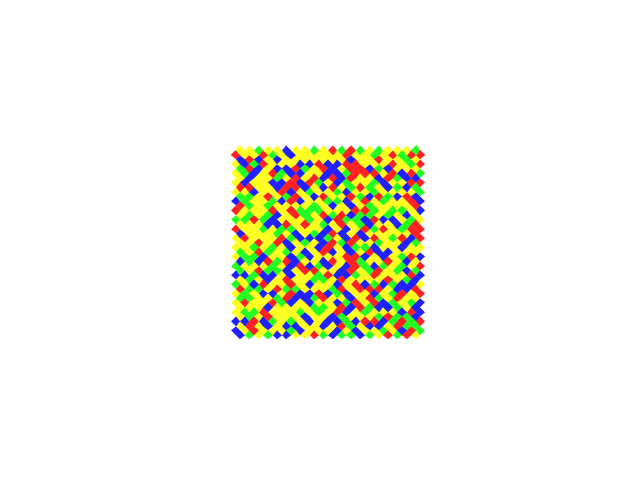

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Example matrix
N = 20
img = (5*np.random.random((2*N,2*N))).astype(int)+1
for m in range(N):
    for n in range(m):
        img[N-m-1,n]=0
        img[N-m-1,2*N-n-1]=0
        img[N+m,n]=0
        img[N+m,2*N-n-1]=0


A = img
m, n = A.shape

# ------------------------------------------------------------
# 1. Build the grid corners of the unrotated square pixels
#    There are (m+1) x (n+1) corners for an m x n image.
# ------------------------------------------------------------
x = np.arange(n + 1)
y = np.arange(m + 1)
X, Y = np.meshgrid(x, y)

# Optional: center the image around the origin before rotation
cx = n / 2
cy = m / 2
Xc = X - cx
Yc = Y - cy

# ------------------------------------------------------------
# 2. Rotate all corners by 45 degrees
# ------------------------------------------------------------
theta = np.deg2rad(45)
c = np.cos(theta)
s = np.sin(theta)

Xr = c * Xc - s * Yc
Yr = s * Xc + c * Yc

# ------------------------------------------------------------
# 3. Colormap
#    0 = white, then your four colors
# ------------------------------------------------------------
cmap = ListedColormap([
    (1, 1, 1),                 # 0 -> white
    (255/255, 33/255, 33/255), # 1 -> red
    (31/255, 31/255, 255/255), # 2 -> blue
    (32/255, 255/255, 32/255), # 3 -> green
    (255/255, 255/255, 32/255) # 4 -> yellow
])

norm = BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
    ncolors=cmap.N
)

# ------------------------------------------------------------
# 4. Plot as vector tiles
# ------------------------------------------------------------
fig, ax = plt.subplots()

pc = ax.pcolormesh(
    Xr, Yr, A,
    cmap=cmap,
    norm=norm,
    shading='flat',
    edgecolors="face",   # optional black borders
    linewidth=0.3,
    antialiased= True
)

ax.set_aspect("equal")
ax.axis("off")
plt.show()

In [70]:
plt.pcolormesh?

Signature:
plt.pcolormesh(
    *args: 'ArrayLike',
    alpha: 'float | None' = None,
    norm: 'str | Normalize | None' = None,
    cmap: 'str | Colormap | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    shading: "Literal['flat', 'nearest', 'gouraud', 'auto'] | None" = None,
    antialiased: 'bool' = False,
    data=None,
    **kwargs,
) -> 'QuadMesh'
Docstring:
Create a pseudocolor plot with a non-regular rectangular grid.

Call signature::

    pcolormesh([X, Y,] C, **kwargs)

*X* and *Y* can be used to specify the corners of the quadrilaterals.

.. hint::

   `~.Axes.pcolormesh` is similar to `~.Axes.pcolor`. It is much faster
   and preferred in most cases. For a detailed discussion on the
   differences see :ref:`Differences between pcolor() and pcolormesh()
   <differences-pcolor-pcolormesh>`.

Parameters
----------
C : array-like
    The mesh data. Supported array shapes are:

    - (M, N) or M*N: a mesh with scalar data. The values are mapped

In [60]:
import RandomTilings as RT
RT.config.set_mpl_backend('interactive')

In [61]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# 0 = white/background
# 1,2,3,4 = domino colors
cmap = ListedColormap([
    (1, 1, 1),             # 0: white
    (255/255, 33/255, 33/255),    # 1: red
    (31/255, 31/255, 255/255),    # 2: blue
    (32/255, 255/255, 32/255),    # 3: green
    (255/255, 255/255, 32/255),   # 4: yellow
])

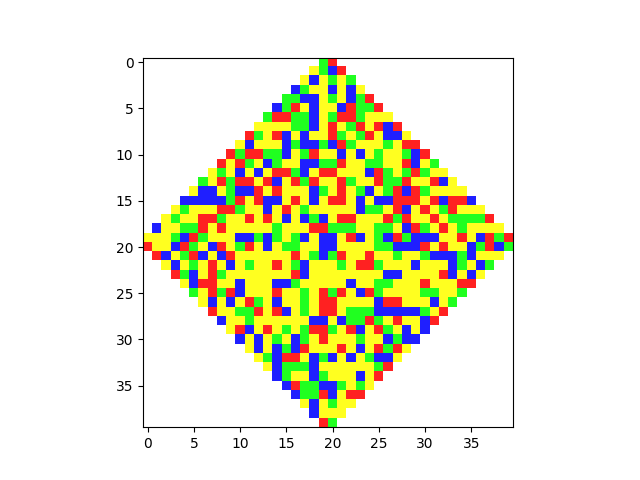

In [63]:
N = 20
img = (5*np.random.random((2*N,2*N))).astype(int)+1
for m in range(N):
    for n in range(m):
        img[N-m-1,n]=0
        img[N-m-1,2*N-n-1]=0
        img[N+m,n]=0
        img[N+m,2*N-n-1]=0
plt.imshow(img,cmap=cmap)
plt.show()

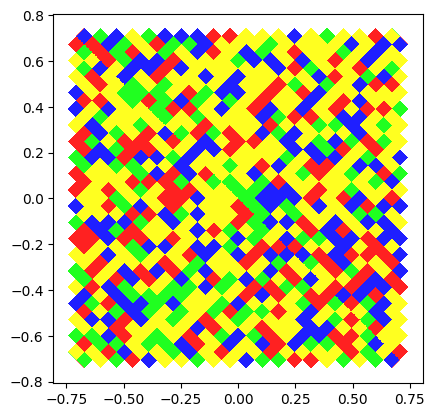

In [59]:
import matplotlib.pyplot as plt
from matplotlib import transforms

def oversample_nearest(img, factor):
    return np.repeat(np.repeat(img, factor, axis=0), factor, axis=1)


factor = 4
img_big = oversample_nearest(img, factor)

fig, ax = plt.subplots()

k = 2
interpol = ["nearest",'lanczos','none'][k]


im = ax.imshow(
    img_big,
    cmap = cmap,
    origin="lower",
    interpolation=interpol,
    extent=[-1,1,-1,1]
)

tr = transforms.Affine2D().rotate_deg(45) + ax.transData
im.set_transform(tr)
s = 1/np.sqrt(2)+0.1
ax.set_xlim(-s, s)
ax.set_ylim(-s, s)
ax.set_aspect("equal")
plt.show()